# Batch Speculative Decoding

**COMS 4232 Final Project — Nikhil Sharma (ns3942) & Mertay Dayanc (md4437)**

This notebook implements **Batch Speculative Decoding** (Algorithm 1 from our formalization),
which extends the baseline by sampling $N$ independent draft paths and selecting the best one.

**References:**
- [Yang et al. (2024) — Multi-Candidate Speculative Decoding](https://arxiv.org/abs/2401.06706)
- [Leviathan et al. (2023) — Fast Inference from Transformers via Speculative Decoding](https://arxiv.org/abs/2211.17192)
- Dayanc & Sharma — *Batch Speculative Decoding: Formalization and Unbiasedness*

**Setup:**
- **Draft model ($M_q$):** GPT-2 small (124M)
- **Target model ($M_p$):** GPT-2 XL (1.5B)
- **Batch size $N$:** Number of independent draft paths per round

**Algorithm overview (per round):**

1. **Phase 1 — Drafting:** Sample $N$ independent paths of length $K$ from $M_q$.
2. **Phase 2 — Parallel Evaluation:** Run $M_p$ on all paths to get target distributions $p_i(x)$.
3. **Phase 3 — Path Selection:** For each path $j$, find its rejection index $i_j$ (first position where $r > p_i(\tilde{x}_i) / q_i(\tilde{x}_i)$). Select $j^* = \arg\max_j(i_j)$.
4. **Phase 4 — Verification & Correction:**
   - If $i_{\max} < K$: sample from the corrected residual $p'_{i_{\max}}(x) = \frac{p_{i_{\max}}(x) - A_{\text{eff}}(x)}{1 - \beta_{\text{batch}}}$ where $A_{\text{eff}}(x) = \min\!\big(p_{i_{\max}}(x),\; 1 - (1 - \min(p_{i_{\max}}(x), q_{i_{\max}}(x)))^N\big)$
   - If $i_{\max} = K$: all tokens of path $j^*$ accepted; sample a bonus token from $p_{t+K}(x)$.

## 1. Imports & Model Loading

In [1]:
import torch
import torch.nn.functional as F
from transformers import AutoModelForCausalLM, AutoTokenizer
import time

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

tokenizer = AutoTokenizer.from_pretrained("gpt2")

# Draft model (GPT-2 small, 124M)
draft_model = AutoModelForCausalLM.from_pretrained("gpt2").to(device)
draft_model.eval()

# Target model (GPT-2 XL, 1.5B)
target_model = AutoModelForCausalLM.from_pretrained("gpt2-xl").to(device)
target_model.eval()

print(f"Draft model parameters:  {sum(p.numel() for p in draft_model.parameters()):,}")
print(f"Target model parameters: {sum(p.numel() for p in target_model.parameters()):,}")
print(f"Vocabulary size: {tokenizer.vocab_size}")

Using device: cuda


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:103: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

...

model.safetensors:   0%|          | 0.00/6.43G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/580 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: gpt2-xl
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...47}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

Draft model parameters:  124,439,808
Target model parameters: 1,557,611,200
Vocabulary size: 50257


## 2. Batch Draft Function (Phase 1)

Sample $N$ independent draft paths, each of length $K$, from the draft model $M_q$.
Each path is generated autoregressively, just like in the baseline — but we do it $N$ times independently.

Returns:
- `all_draft_tokens`: list of $N$ token sequences (each length $K$)
- `all_draft_probs`: list of $N$ probability distribution sequences (each length $K$)

In [2]:
@torch.no_grad()
def batch_draft(
    input_ids: torch.Tensor, N: int, K: int
) -> tuple[list[list[int]], list[list[torch.Tensor]]]:
    """
    Phase 1: Sample N independent draft paths of length K.

    This version batches the N paths at each draft step. The K autoregressive
    steps are still sequential, but each step uses one draft-model forward pass
    with batch size N instead of N separate forward passes.

    Args:
        input_ids: Prefix token IDs, shape (1, seq_len).
        N: Number of independent draft paths (batch size).
        K: Draft length per path.

    Returns:
        all_draft_tokens: List of N lists, each containing K token IDs.
        all_draft_probs:  List of N lists, each containing K probability
                          distributions (shape (vocab_size,)).
    """
    current_ids = input_ids.repeat(N, 1)  # (N, seq_len)
    all_draft_tokens = [[] for _ in range(N)]
    all_draft_probs = [[] for _ in range(N)]

    for _ in range(K):
        outputs = draft_model(current_ids)
        logits = outputs.logits[:, -1, :]  # (N, vocab_size)
        probs = F.softmax(logits, dim=-1)
        tokens = torch.multinomial(probs, num_samples=1)  # (N, 1)

        for j in range(N):
            all_draft_tokens[j].append(tokens[j, 0].item())
            all_draft_probs[j].append(probs[j].detach())

        current_ids = torch.cat([current_ids, tokens], dim=1)

    return all_draft_tokens, all_draft_probs

## 3. Batch Verification (Phases 2–4)

This is the core of the batch algorithm, implementing Phases 2–4:

**Phase 2 — Parallel Evaluation:** Run target model on each path (prefix + draft tokens) to get $p_i(x)$.

**Phase 3 — Path Selection:** For each path $j$, simulate the baseline accept/reject to find the rejection index $i_j$ (the first position where $r > p_i(\tilde{x}_i)/q_i(\tilde{x}_i)$). Select $j^* = \arg\max_j(i_j)$ and $i_{\max} = \max_j(i_j)$.

**Phase 4 — Verification & Correction:**
- If $i_{\max} < K$ (best path was rejected at some position):
  - Compute the **effective acceptance** (Eq. 1 from our proof):
    $$A_{\text{eff}}(x) = \min\!\big(p_{i_{\max}}(x),\; 1 - (1 - \min(p_{i_{\max}}(x),\, q_{i_{\max}}(x)))^N\big)$$
  - Compute $\beta_{\text{batch}} = \sum_x A_{\text{eff}}(x)$
  - Sample from the **corrected residual** (Eq. 3):
    $$p'_{i_{\max}}(x) = \frac{p_{i_{\max}}(x) - A_{\text{eff}}(x)}{1 - \beta_{\text{batch}}}$$
- If $i_{\max} = K$ (full path $j^*$ accepted): sample a bonus token from $p_{t+K}(x)$.

The clipping in $A_{\text{eff}}$ is what prevents the over-sampling bias described in Section 3 of our proof.

In [3]:
@torch.no_grad()
def batch_verify(
    prefix_ids: torch.Tensor,
    all_draft_tokens: list[list[int]],
    all_draft_probs: list[list[torch.Tensor]],
) -> tuple[list[int], int]:
    """
    Phases 2-4: Evaluate all N paths on the target model, select the best
    path, and apply the A_eff correction on rejection.

    This version evaluates the N candidate paths in one batched target-model
    call. That matches the intended parallel-evaluation cost model better than
    looping over paths with N separate target forwards.
    """
    N = len(all_draft_tokens)
    K = len(all_draft_tokens[0])
    n = prefix_ids.shape[1]

    # ------------------------------------------------------------------
    # Phase 2: Run target model once on a batch of N paths.
    # ------------------------------------------------------------------
    draft_tensor = torch.tensor(all_draft_tokens, device=device)  # (N, K)
    prefix_batch = prefix_ids.repeat(N, 1)  # (N, n)
    full_ids = torch.cat([prefix_batch, draft_tensor], dim=1)  # (N, n+K)

    outputs = target_model(full_ids)
    target_probs = F.softmax(outputs.logits[:, n - 1 : n + K, :], dim=-1)
    # target_probs[j, t] predicts the token at position n+t for path j.
    # t=0..K-1 are draft positions; t=K is the bonus-token distribution.

    # ------------------------------------------------------------------
    # Phase 3: Path Selection — find rejection index for each path.
    # ------------------------------------------------------------------
    rejection_indices = []
    for j in range(N):
        i_j = K
        for t in range(K):
            x_t = all_draft_tokens[j][t]
            p_x = target_probs[j, t, x_t].item()
            q_x = all_draft_probs[j][t][x_t].item()
            acceptance_prob = 0.0 if q_x == 0 else min(1.0, p_x / q_x)

            r = torch.rand(1).item()
            if r > acceptance_prob:
                i_j = t
                break
        rejection_indices.append(i_j)

    i_max = max(rejection_indices)
    j_star = rejection_indices.index(i_max)

    # ------------------------------------------------------------------
    # Phase 4: Verification & Correction
    # ------------------------------------------------------------------
    accepted_tokens = list(all_draft_tokens[j_star][:i_max])
    n_accepted = i_max

    if i_max < K:
        p_imax = target_probs[j_star, i_max]
        q_imax = all_draft_probs[j_star][i_max]

        overlap = torch.min(p_imax, q_imax)
        raw_batch_accept = 1.0 - (1.0 - overlap).pow(N)
        A_eff = torch.min(p_imax, raw_batch_accept)

        residual = torch.clamp(p_imax - A_eff, min=0.0)
        residual_sum = residual.sum()
        residual = residual / residual_sum if residual_sum > 0 else p_imax

        resampled_token = torch.multinomial(residual, num_samples=1).item()
        accepted_tokens.append(resampled_token)
    else:
        bonus_probs = target_probs[j_star, K]
        bonus_token = torch.multinomial(bonus_probs, num_samples=1).item()
        accepted_tokens.append(bonus_token)

    return accepted_tokens, n_accepted

## 4. Batch Speculative Decoding — Outer Loop

Repeatedly calls `batch_draft()` and `batch_verify()` until we reach `max_new_tokens` or EOS.
Tracks acceptance metrics to compare against the baseline.

In [4]:
@torch.no_grad()
def batch_speculative_decode(
    prompt: str,
    N: int = 2,
    K: int = 4,
    max_new_tokens: int = 50,
) -> dict:
    """
    Generate text using batch speculative decoding.

    Args:
        prompt:         Input text prompt.
        N:              Number of independent draft paths per round.
        K:              Draft length per path.
        max_new_tokens: Maximum new tokens to generate.

    Returns:
        Dictionary with generation results and metrics.
    """
    input_ids = tokenizer.encode(prompt, return_tensors="pt").to(device)
    generated_ids = input_ids.clone()
    eos_token_id = tokenizer.eos_token_id

    total_accepted = 0
    chosen_path_drafted = 0
    total_draft_compute_tokens = 0
    rounds = 0
    target_calls = 0
    draft_calls = 0
    target_sequences_evaluated = 0

    start_time = time.time()

    tokens_generated = 0
    while tokens_generated < max_new_tokens:
        # Phase 1: Draft N paths of length K.
        all_draft_tokens, all_draft_probs = batch_draft(generated_ids, N, K)
        draft_calls += K  # K batched draft forwards, each with batch size N
        total_draft_compute_tokens += N * K

        # Phases 2-4: Verify and correct.
        accepted_tokens, n_accepted = batch_verify(
            generated_ids, all_draft_tokens, all_draft_probs
        )
        target_calls += 1  # one batched target forward for all N paths
        target_sequences_evaluated += N

        total_accepted += n_accepted
        chosen_path_drafted += K
        rounds += 1

        new_tokens = torch.tensor([accepted_tokens], device=device)
        generated_ids = torch.cat([generated_ids, new_tokens], dim=1)
        tokens_generated += len(accepted_tokens)

        if eos_token_id in accepted_tokens:
            break

    elapsed = time.time() - start_time
    output_text = tokenizer.decode(generated_ids[0], skip_special_tokens=True)
    best_path_acceptance_rate = (
        total_accepted / chosen_path_drafted if chosen_path_drafted > 0 else 0.0
    )
    compute_adjusted_acceptance_rate = (
        total_accepted / total_draft_compute_tokens
        if total_draft_compute_tokens > 0
        else 0.0
    )

    return {
        "text": output_text,
        "tokens_generated": tokens_generated,
        "rounds": rounds,
        "total_accepted": total_accepted,
        "total_drafted": chosen_path_drafted,  # kept for backward compatibility
        "chosen_path_drafted_tokens": chosen_path_drafted,
        "total_draft_compute_tokens": total_draft_compute_tokens,
        "acceptance_rate": best_path_acceptance_rate,
        "best_path_acceptance_rate": best_path_acceptance_rate,
        "compute_adjusted_acceptance_rate": compute_adjusted_acceptance_rate,
        "time": elapsed,
        "target_calls": target_calls,
        "target_sequences_evaluated": target_sequences_evaluated,
        "draft_calls": draft_calls,
        "draft_sequences_sampled": rounds * N,
        "N": N,
        "K": K,
    }

## 5. Vanilla Autoregressive Baseline

Same as in the baseline notebook — target model only, one forward pass per token.

In [5]:
@torch.no_grad()
def autoregressive_generate(
    prompt: str,
    max_new_tokens: int = 50,
) -> dict:
    """Standard autoregressive generation using the target model."""
    input_ids = tokenizer.encode(prompt, return_tensors="pt").to(device)
    generated_ids = input_ids.clone()
    eos_token_id = tokenizer.eos_token_id

    start_time = time.time()

    tokens_generated = 0
    for _ in range(max_new_tokens):
        outputs = target_model(generated_ids)
        logits = outputs.logits[0, -1, :]
        probs = F.softmax(logits, dim=-1)
        token = torch.multinomial(probs, num_samples=1).item()

        generated_ids = torch.cat(
            [generated_ids, torch.tensor([[token]], device=device)], dim=1
        )
        tokens_generated += 1

        if token == eos_token_id:
            break

    elapsed = time.time() - start_time
    output_text = tokenizer.decode(generated_ids[0], skip_special_tokens=True)

    return {
        "text": output_text,
        "tokens_generated": tokens_generated,
        "time": elapsed,
        "target_calls": tokens_generated,
    }

## 6. Single-Run Comparison

Compare batch speculative decoding (N=2, K=4) against vanilla autoregressive on a single prompt.
The key question: does sampling multiple draft paths improve the acceptance rate compared to the baseline (N=1)?

In [6]:
prompt = "The future of artificial intelligence is"
N = 2
K = 4
max_new_tokens = 50

print(f'Prompt: "{prompt}"')
print(f"Batch size N = {N}, Draft length K = {K}, max_new_tokens = {max_new_tokens}")
print("=" * 70)

# --- Batch Speculative Decoding ---
print("\n[Batch Speculative Decoding]")
batch_result = batch_speculative_decode(prompt, N=N, K=K, max_new_tokens=max_new_tokens)

print(f"Generated text:\n  {batch_result['text']}\n")
print(f"  Tokens generated:          {batch_result['tokens_generated']}")
print(f"  Rounds:                    {batch_result['rounds']}")
print(f"  Chosen-path draft tokens:  {batch_result['chosen_path_drafted_tokens']}")
print(f"  Total draft compute tokens:{batch_result['total_draft_compute_tokens']}")
print(f"  Draft tokens accepted:     {batch_result['total_accepted']}")
print(f"  Best-path acceptance rate: {batch_result['best_path_acceptance_rate']:.2%}")
print(f"  Compute-adjusted accept:   {batch_result['compute_adjusted_acceptance_rate']:.2%}")
print(f"  Target model calls:        {batch_result['target_calls']} batched calls")
print(f"  Target sequences eval'd:   {batch_result['target_sequences_evaluated']}")
print(f"  Draft model calls:         {batch_result['draft_calls']} batched calls")
print(f"  Wall-clock time:           {batch_result['time']:.2f}s")

# --- Vanilla Autoregressive ---
print("\n" + "=" * 70)
print("\n[Vanilla Autoregressive (target model only)]")
ar_result = autoregressive_generate(prompt, max_new_tokens=max_new_tokens)

print(f"Generated text:\n  {ar_result['text']}\n")
print(f"  Tokens generated:   {ar_result['tokens_generated']}")
print(f"  Target model calls: {ar_result['target_calls']}")
print(f"  Wall-clock time:    {ar_result['time']:.2f}s")

# --- Summary ---
print("\n" + "=" * 70)
print("\n[Summary]")
print(f"  Batch SD used {batch_result['target_calls']} batched target calls vs {ar_result['target_calls']} AR calls.")
print(f"  It evaluated {batch_result['target_sequences_evaluated']} target sequences total.")
print(f"  Wall-clock speedup: {ar_result['time'] / batch_result['time']:.2f}x")
print(f"  Best-path acceptance rate: {batch_result['best_path_acceptance_rate']:.2%}")
print(f"  Compute-adjusted acceptance rate: {batch_result['compute_adjusted_acceptance_rate']:.2%}")


Prompt: "The future of artificial intelligence is"
Batch size N = 2, Draft length K = 4, max_new_tokens = 50

[Batch Speculative Decoding]
Generated text:
  The future of artificial intelligence is bright" was one of this week's best news stories (PDF), saying that big companies like Microsoft, Google, and Amazon want to preserve their human resources - including their current "cognitive workforce" - that could other ways to improve many of our

  Tokens generated:          50
  Rounds:                    16
  Chosen-path draft tokens:  64
  Total draft compute tokens:128
  Draft tokens accepted:     34
  Best-path acceptance rate: 53.12%
  Compute-adjusted accept:   26.56%
  Target model calls:        16 batched calls
  Target sequences eval'd:   32
  Draft model calls:         64 batched calls
  Wall-clock time:           2.53s


[Vanilla Autoregressive (target model only)]
Generated text:
  The future of artificial intelligence is in humans as much as computers

  Tokens generated: 

## 7. Averaged Comparison (Multiple Runs)

Run both methods multiple times and average for stable metrics.
This lets us reliably compare batch SD acceptance rates against the baseline notebook's ~47% average.

In [7]:
prompt = "The future of artificial intelligence is"
N = 2
K = 4
max_new_tokens = 50
n_runs = 10

print(f"Running {n_runs} trials | N = {N}, K = {K}, max_new_tokens = {max_new_tokens}")
print(f'Prompt: "{prompt}"')
print("=" * 70)

# Collect metrics
batch_times = []
batch_best_acceptance_rates = []
batch_compute_acceptance_rates = []
batch_target_calls = []
batch_target_sequences = []
batch_draft_calls = []
batch_tokens = []

ar_times = []
ar_target_calls = []

for i in range(n_runs):
    br = batch_speculative_decode(prompt, N=N, K=K, max_new_tokens=max_new_tokens)
    batch_times.append(br["time"])
    batch_best_acceptance_rates.append(br["best_path_acceptance_rate"])
    batch_compute_acceptance_rates.append(br["compute_adjusted_acceptance_rate"])
    batch_target_calls.append(br["target_calls"])
    batch_target_sequences.append(br["target_sequences_evaluated"])
    batch_draft_calls.append(br["draft_calls"])
    batch_tokens.append(br["tokens_generated"])

    ar = autoregressive_generate(prompt, max_new_tokens=max_new_tokens)
    ar_times.append(ar["time"])
    ar_target_calls.append(ar["target_calls"])

    print(f"  Trial {i+1:2d}: batch {br['time']:.2f}s "
          f"(best accept {br['best_path_acceptance_rate']:.0%}, "
          f"compute accept {br['compute_adjusted_acceptance_rate']:.0%}, "
          f"rounds {br['rounds']}) | AR {ar['time']:.2f}s")

# Averages
avg_batch_time = sum(batch_times) / n_runs
avg_ar_time = sum(ar_times) / n_runs
avg_best_acceptance = sum(batch_best_acceptance_rates) / n_runs
avg_compute_acceptance = sum(batch_compute_acceptance_rates) / n_runs
avg_batch_target = sum(batch_target_calls) / n_runs
avg_batch_target_sequences = sum(batch_target_sequences) / n_runs
avg_batch_draft = sum(batch_draft_calls) / n_runs
avg_ar_target = sum(ar_target_calls) / n_runs
avg_batch_tokens = sum(batch_tokens) / n_runs

print("\n" + "=" * 70)
print(f"\n[Averaged over {n_runs} runs]")
print(f"  Batch Speculative Decoding (N={N}, K={K}):")
print(f"    Avg time:                     {avg_batch_time:.2f}s")
print(f"    Avg best-path acceptance:     {avg_best_acceptance:.2%}")
print(f"    Avg compute-adjusted accept:  {avg_compute_acceptance:.2%}")
print(f"    Avg target batched calls:     {avg_batch_target:.1f}")
print(f"    Avg target sequences eval'd:  {avg_batch_target_sequences:.1f}")
print(f"    Avg draft batched calls:      {avg_batch_draft:.1f}")
print(f"    Avg tokens generated:         {avg_batch_tokens:.1f}")
print(f"  Autoregressive:")
print(f"    Avg time:                     {avg_ar_time:.2f}s")
print(f"    Avg target calls:             {avg_ar_target:.1f}")
print(f"\n  Avg wall-clock speedup: {avg_ar_time / avg_batch_time:.2f}x")
print(f"  Avg target call reduction: {avg_ar_target:.0f} -> {avg_batch_target:.0f} batched calls")
print(f"\n  Compare to baseline SD (N=1): ~47% acceptance rate")
print(f"  Batch SD (N={N}): {avg_best_acceptance:.2%} best-path acceptance rate")


Running 10 trials | N = 2, K = 4, max_new_tokens = 50
Prompt: "The future of artificial intelligence is"
  Trial  1: batch 1.37s (best accept 50%, compute accept 25%, rounds 17) | AR 1.88s
  Trial  2: batch 1.14s (best accept 68%, compute accept 34%, rounds 14) | AR 1.89s
  Trial  3: batch 1.34s (best accept 53%, compute accept 26%, rounds 17) | AR 1.90s
  Trial  4: batch 1.03s (best accept 71%, compute accept 36%, rounds 13) | AR 1.86s
  Trial  5: batch 1.02s (best accept 71%, compute accept 36%, rounds 13) | AR 1.86s
  Trial  6: batch 1.35s (best accept 49%, compute accept 24%, rounds 17) | AR 1.86s
  Trial  7: batch 1.26s (best accept 56%, compute accept 28%, rounds 16) | AR 1.87s
  Trial  8: batch 1.25s (best accept 55%, compute accept 27%, rounds 16) | AR 1.87s
  Trial  9: batch 1.10s (best accept 66%, compute accept 33%, rounds 14) | AR 1.87s
  Trial 10: batch 1.03s (best accept 71%, compute accept 36%, rounds 13) | AR 1.86s


[Averaged over 10 runs]
  Batch Speculative Decoding 

## 8. WikiText Prompt Dataset

This section creates or loads a local `wikitext_prompts.csv` file. In Colab, run this after cloning/uploading the project folder. The helper script downloads WikiText from Hugging Face, filters short headings/blank lines, and saves a fixed prompt list for reproducible experiments.

In [10]:
from pathlib import Path
import csv
import re
import subprocess
import sys

import pandas as pd

PROMPT_CSV = Path("wikitext_prompts.csv")
NUM_PROMPTS = 50


def normalize_prompt_line(text: str) -> str:
    return re.sub(r"\s+", " ", text.strip())


def is_usable_prompt(text: str, min_words: int = 12, max_words: int = 60) -> bool:
    if not text:
        return False
    if text.startswith("=") and text.endswith("="):
        return False
    words = text.split()
    if len(words) < min_words or len(words) > max_words:
        return False
    if sum(ch.isalpha() for ch in text) < 0.6 * len(text):
        return False
    return True


def create_wikitext_prompt_csv(output_path: Path, num_prompts: int = 50) -> None:
    try:
        from datasets import load_dataset
    except ImportError:
        print("Installing datasets because it is not available in this runtime...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "datasets"])
        from datasets import load_dataset

    dataset = load_dataset("wikitext", "wikitext-2-raw-v1", split="test")
    prompts = []
    seen = set()

    for row in dataset:
        prompt = normalize_prompt_line(row.get("text", ""))
        if not is_usable_prompt(prompt):
            continue
        if prompt in seen:
            continue
        seen.add(prompt)
        prompts.append(prompt)
        if len(prompts) >= num_prompts:
            break

    if len(prompts) < num_prompts:
        raise RuntimeError(f"Only found {len(prompts)} usable prompts; requested {num_prompts}.")

    with output_path.open("w", newline="", encoding="utf-8") as f:
        writer = csv.DictWriter(f, fieldnames=["prompt_id", "prompt"])
        writer.writeheader()
        for prompt_id, prompt in enumerate(prompts):
            writer.writerow({"prompt_id": prompt_id, "prompt": prompt})

    print(f"Wrote {len(prompts)} prompts to {output_path}")


if not PROMPT_CSV.exists():
    script_path = Path("load_wikitext_prompts.py")
    if script_path.exists():
        subprocess.check_call([
            sys.executable,
            str(script_path),
            "--num-prompts",
            str(NUM_PROMPTS),
            "--output",
            str(PROMPT_CSV),
        ])
    else:
        print("load_wikitext_prompts.py not found in the current Colab directory; creating prompts inline.")
        create_wikitext_prompt_csv(PROMPT_CSV, NUM_PROMPTS)

prompts_df = pd.read_csv(PROMPT_CSV)
prompts = prompts_df["prompt"].tolist()
print(f"Loaded {len(prompts)} prompts from {PROMPT_CSV.resolve()}")
prompts_df.head()


load_wikitext_prompts.py not found in the current Colab directory; creating prompts inline.


README.md: 0.00B [00:00, ?B/s]

wikitext-2-raw-v1/test-00000-of-00001.pa(…):   0%|          | 0.00/733k [00:00<?, ?B/s]

wikitext-2-raw-v1/train-00000-of-00001.p(…):   0%|          | 0.00/6.36M [00:00<?, ?B/s]

wikitext-2-raw-v1/validation-00000-of-00(…):   0%|          | 0.00/657k [00:00<?, ?B/s]

Generating test split:   0%|          | 0/4358 [00:00<?, ? examples/s]

Generating train split:   0%|          | 0/36718 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/3760 [00:00<?, ? examples/s]

Wrote 50 prompts to wikitext_prompts.csv
Loaded 50 prompts from /content/wikitext_prompts.csv


,prompt_id,prompt
0,0,Du Fu 's mother died shortly after he was born...
1,1,"The son of a minor scholar @-@ official , his ..."
2,2,"Brooding on what I have lived through , if eve..."
3,3,I am about to scream madly in the office / Esp...
4,4,He moved on in the summer of 759 ; this has tr...


## 9. Multi-Prompt Experiment Grid

This grid runs autoregressive decoding once per prompt, then runs batch speculative decoding for each `(N, K)` setting. Results are appended to `batch_wikitext_results.csv` after every run so partial Colab runs are still usable.

In [11]:
from itertools import product
import time

RESULTS_CSV = Path("batch_wikitext_results.csv")

# Start with a modest grid. Increase after the first run looks sane.
N_VALUES = [1, 2, 4]
K_VALUES = [2, 4, 6, 8]
MAX_NEW_TOKENS = 50
PROMPT_LIMIT = min(50, len(prompts))

print(f"Experiment grid: {PROMPT_LIMIT} prompts x {len(N_VALUES)} N values x {len(K_VALUES)} K values")
print(f"Total batch runs: {PROMPT_LIMIT * len(N_VALUES) * len(K_VALUES)}")
print(f"Results will be saved to {RESULTS_CSV}")

Experiment grid: 50 prompts x 3 N values x 4 K values
Total batch runs: 600
Results will be saved to batch_wikitext_results.csv


In [12]:
def append_result(row: dict, output_path: Path = RESULTS_CSV) -> None:
    row_df = pd.DataFrame([row])
    row_df.to_csv(
        output_path,
        mode="a",
        header=not output_path.exists(),
        index=False,
    )


def run_wikitext_grid(
    prompts: list[str],
    n_values: list[int],
    k_values: list[int],
    max_new_tokens: int = 50,
    prompt_limit: int | None = None,
    output_path: Path = RESULTS_CSV,
    resume: bool = True,
) -> pd.DataFrame:
    selected_prompts = prompts[:prompt_limit] if prompt_limit is not None else prompts

    completed = set()
    if resume and output_path.exists():
        existing = pd.read_csv(output_path)
        for row in existing.itertuples(index=False):
            completed.add((int(row.prompt_id), int(row.N), int(row.K)))
        print(f"Resuming from {output_path}: {len(completed)} completed batch runs")

    ar_cache: dict[int, dict] = {}
    total_runs = len(selected_prompts) * len(n_values) * len(k_values)
    run_idx = 0

    for prompt_id, prompt in enumerate(selected_prompts):
        if prompt_id not in ar_cache:
            ar = autoregressive_generate(prompt, max_new_tokens=max_new_tokens)
            ar_cache[prompt_id] = ar
        else:
            ar = ar_cache[prompt_id]

        for N, K in product(n_values, k_values):
            run_idx += 1
            key = (prompt_id, N, K)
            if resume and key in completed:
                continue

            print(f"[{run_idx}/{total_runs}] prompt={prompt_id} N={N} K={K}")
            br = batch_speculative_decode(
                prompt,
                N=N,
                K=K,
                max_new_tokens=max_new_tokens,
            )

            row = {
                "prompt_id": prompt_id,
                "prompt": prompt,
                "N": N,
                "K": K,
                "max_new_tokens": max_new_tokens,
                "batch_tokens_generated": br["tokens_generated"],
                "batch_rounds": br["rounds"],
                "batch_time": br["time"],
                "batch_tokens_per_second": br["tokens_generated"] / br["time"] if br["time"] > 0 else float("nan"),
                "batch_target_calls": br["target_calls"],
                "batch_target_sequences_evaluated": br["target_sequences_evaluated"],
                "batch_draft_calls": br["draft_calls"],
                "batch_total_accepted": br["total_accepted"],
                "chosen_path_drafted_tokens": br["chosen_path_drafted_tokens"],
                "total_draft_compute_tokens": br["total_draft_compute_tokens"],
                "best_path_acceptance_rate": br["best_path_acceptance_rate"],
                "compute_adjusted_acceptance_rate": br["compute_adjusted_acceptance_rate"],
                "generated_tokens_per_target_call": br["tokens_generated"] / br["target_calls"] if br["target_calls"] > 0 else float("nan"),
                "ar_tokens_generated": ar["tokens_generated"],
                "ar_time": ar["time"],
                "ar_target_calls": ar["target_calls"],
                "speedup_vs_ar": ar["time"] / br["time"] if br["time"] > 0 else float("nan"),
            }
            append_result(row, output_path)

    return pd.read_csv(output_path)


results_df = run_wikitext_grid(
    prompts,
    N_VALUES,
    K_VALUES,
    max_new_tokens=MAX_NEW_TOKENS,
    prompt_limit=PROMPT_LIMIT,
    output_path=RESULTS_CSV,
    resume=True,
)

print(f"Saved {len(results_df)} rows to {RESULTS_CSV}")
results_df.head()

[1/600] prompt=0 N=1 K=2
[2/600] prompt=0 N=1 K=4
[3/600] prompt=0 N=1 K=6
[4/600] prompt=0 N=1 K=8
[5/600] prompt=0 N=2 K=2
[6/600] prompt=0 N=2 K=4
[7/600] prompt=0 N=2 K=6
[8/600] prompt=0 N=2 K=8
[9/600] prompt=0 N=4 K=2
[10/600] prompt=0 N=4 K=4
[11/600] prompt=0 N=4 K=6
[12/600] prompt=0 N=4 K=8
[13/600] prompt=1 N=1 K=2
[14/600] prompt=1 N=1 K=4
[15/600] prompt=1 N=1 K=6
[16/600] prompt=1 N=1 K=8
[17/600] prompt=1 N=2 K=2
[18/600] prompt=1 N=2 K=4
[19/600] prompt=1 N=2 K=6
[20/600] prompt=1 N=2 K=8
[21/600] prompt=1 N=4 K=2
[22/600] prompt=1 N=4 K=4
[23/600] prompt=1 N=4 K=6
[24/600] prompt=1 N=4 K=8
[25/600] prompt=2 N=1 K=2
[26/600] prompt=2 N=1 K=4
[27/600] prompt=2 N=1 K=6
[28/600] prompt=2 N=1 K=8
[29/600] prompt=2 N=2 K=2
[30/600] prompt=2 N=2 K=4
[31/600] prompt=2 N=2 K=6
[32/600] prompt=2 N=2 K=8
[33/600] prompt=2 N=4 K=2
[34/600] prompt=2 N=4 K=4
[35/600] prompt=2 N=4 K=6
[36/600] prompt=2 N=4 K=8
[37/600] prompt=3 N=1 K=2
[38/600] prompt=3 N=1 K=4
[39/600] prompt=3 N=1

,prompt_id,prompt,N,K,max_new_tokens,batch_tokens_generated,batch_rounds,batch_time,batch_tokens_per_second,batch_target_calls,...,batch_total_accepted,chosen_path_drafted_tokens,total_draft_compute_tokens,best_path_acceptance_rate,compute_adjusted_acceptance_rate,generated_tokens_per_target_call,ar_tokens_generated,ar_time,ar_target_calls,speedup_vs_ar
0,0,Du Fu 's mother died shortly after he was born...,1,2,50,52,23,1.377137,37.759492,23,...,29,46,46,0.630435,0.630435,2.260870,50,1.910329,50,1.387174
1,0,Du Fu 's mother died shortly after he was born...,1,4,50,50,20,1.580653,31.632502,20,...,30,80,80,0.375000,0.375000,2.500000,50,1.910329,50,1.208569
2,0,Du Fu 's mother died shortly after he was born...,1,6,50,26,15,1.481836,17.545806,15,...,11,90,90,0.122222,0.122222,1.733333,50,1.910329,50,1.289164
3,0,Du Fu 's mother died shortly after he was born...,1,8,50,55,22,2.619335,20.997698,22,...,33,176,176,0.187500,0.187500,2.500000,50,1.910329,50,0.729318
4,0,Du Fu 's mother died shortly after he was born...,2,2,50,51,20,1.462800,34.864637,20,...,31,40,80,0.775000,0.387500,2.550000,50,1.910329,50,1.305939


## 10. Quick Results Summary

Use this after the grid finishes, or after a partial run, to see which `(N, K)` settings are promising.

In [13]:
results_df = pd.read_csv(RESULTS_CSV)

summary = (
    results_df
    .groupby(["N", "K"], as_index=False)
    .agg(
        runs=("prompt_id", "count"),
        avg_speedup_vs_ar=("speedup_vs_ar", "mean"),
        median_speedup_vs_ar=("speedup_vs_ar", "median"),
        avg_best_path_acceptance=("best_path_acceptance_rate", "mean"),
        avg_compute_adjusted_acceptance=("compute_adjusted_acceptance_rate", "mean"),
        avg_generated_tokens_per_target_call=("generated_tokens_per_target_call", "mean"),
        avg_batch_time=("batch_time", "mean"),
        avg_ar_time=("ar_time", "mean"),
    )
    .sort_values("avg_speedup_vs_ar", ascending=False)
)

summary

,N,K,runs,avg_speedup_vs_ar,median_speedup_vs_ar,avg_best_path_acceptance,avg_compute_adjusted_acceptance,avg_generated_tokens_per_target_call,avg_batch_time,avg_ar_time
4,2,2,50,2.123502,1.430244,0.765470,0.382735,2.530940,1.270056,1.901697
0,1,2,50,1.941491,1.329800,0.553138,0.553138,2.106276,1.420863,1.901697
1,1,4,50,1.759386,1.209832,0.396373,0.396373,2.585492,1.536922,1.901697
9,4,4,50,1.744900,1.340492,0.769931,0.192483,4.079724,1.429675,1.901697
10,4,6,50,1.671721,1.284313,0.629926,0.157481,4.779554,1.463563,1.901697
11,4,8,50,1.615613,1.166496,0.531765,0.132941,5.254116,1.605219,1.901697
8,4,2,50,1.460637,1.222633,0.903019,0.225755,2.806039,1.560461,1.901697
5,2,4,50,1.380863,1.336608,0.545086,0.272543,3.180346,1.417734,1.901697
6,2,6,50,1.297201,1.253986,0.455148,0.227574,3.730890,1.534716,1.901697
7,2,8,50,1.153969,1.115964,0.391198,0.195599,4.129588,1.723834,1.901697


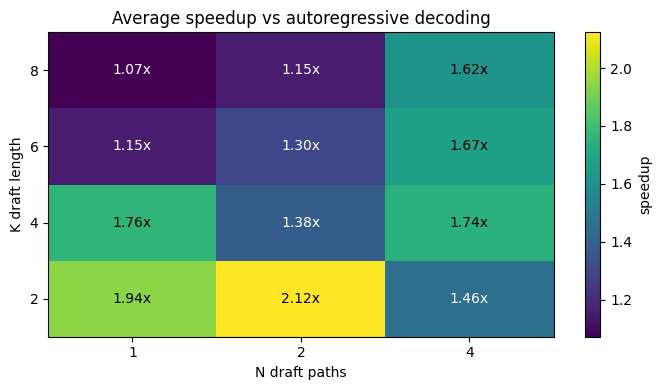

In [14]:
import matplotlib.pyplot as plt

pivot = summary.pivot(index="K", columns="N", values="avg_speedup_vs_ar")

fig, ax = plt.subplots(figsize=(7, 4))
im = ax.imshow(pivot.values, aspect="auto", origin="lower")
ax.set_xticks(range(len(pivot.columns)))
ax.set_xticklabels(pivot.columns)
ax.set_yticks(range(len(pivot.index)))
ax.set_yticklabels(pivot.index)
ax.set_xlabel("N draft paths")
ax.set_ylabel("K draft length")
ax.set_title("Average speedup vs autoregressive decoding")
fig.colorbar(im, ax=ax, label="speedup")

for i, k in enumerate(pivot.index):
    for j, n in enumerate(pivot.columns):
        value = pivot.loc[k, n]
        ax.text(j, i, f"{value:.2f}x", ha="center", va="center", color="white" if value < pivot.values.mean() else "black")

plt.tight_layout()
plt.show()

## 11. Dolly 15k Instruction-Prompt Dataset

Dolly 15k gives a second prompt source that is meaningfully different from WikiText: short instruction-style prompts instead of encyclopedia continuation text. This lets us test whether the `(N, K)` tradeoff changes across prompt distributions.

In [ ]:
DOLLY_PROMPT_CSV = Path("dolly_prompts.csv")
DOLLY_NUM_PROMPTS = 50


def make_dolly_prompt(instruction: str, context: str) -> str:
    instruction = normalize_prompt_line(instruction)
    context = normalize_prompt_line(context)
    if context:
        return f"{instruction}\n\nContext: {context}"
    return instruction


def is_usable_dolly_prompt(prompt: str, min_words: int = 6, max_words: int = 80) -> bool:
    if not prompt:
        return False
    words = prompt.split()
    if len(words) < min_words or len(words) > max_words:
        return False
    if sum(ch.isalpha() for ch in prompt) < 0.5 * len(prompt):
        return False
    return True


def create_dolly_prompt_csv(output_path: Path, num_prompts: int = 50) -> None:
    try:
        from datasets import load_dataset
    except ImportError:
        print("Installing datasets because it is not available in this runtime...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "datasets"])
        from datasets import load_dataset

    dataset = load_dataset("databricks/databricks-dolly-15k", split="train")
    prompts = []
    seen = set()

    for row in dataset:
        prompt = make_dolly_prompt(row.get("instruction", ""), row.get("context", ""))
        if not is_usable_dolly_prompt(prompt):
            continue
        if prompt in seen:
            continue
        seen.add(prompt)
        prompts.append(prompt)
        if len(prompts) >= num_prompts:
            break

    if len(prompts) < num_prompts:
        raise RuntimeError(f"Only found {len(prompts)} usable prompts; requested {num_prompts}.")

    with output_path.open("w", newline="", encoding="utf-8") as f:
        writer = csv.DictWriter(f, fieldnames=["prompt_id", "prompt"])
        writer.writeheader()
        for prompt_id, prompt in enumerate(prompts):
            writer.writerow({"prompt_id": prompt_id, "prompt": prompt})

    print(f"Wrote {len(prompts)} prompts to {output_path}")


if not DOLLY_PROMPT_CSV.exists():
    script_path = Path("load_dolly_prompts.py")
    if script_path.exists():
        subprocess.check_call([
            sys.executable,
            str(script_path),
            "--num-prompts",
            str(DOLLY_NUM_PROMPTS),
            "--output",
            str(DOLLY_PROMPT_CSV),
        ])
    else:
        print("load_dolly_prompts.py not found in the current Colab directory; creating Dolly prompts inline.")
        create_dolly_prompt_csv(DOLLY_PROMPT_CSV, DOLLY_NUM_PROMPTS)

dolly_prompts_df = pd.read_csv(DOLLY_PROMPT_CSV)
dolly_prompts = dolly_prompts_df["prompt"].tolist()
print(f"Loaded {len(dolly_prompts)} prompts from {DOLLY_PROMPT_CSV.resolve()}")
dolly_prompts_df.head()

## 12. Dolly 15k Experiment Grid

This reuses the same experiment settings as the WikiText grid and writes separate results to `batch_dolly_results.csv`. Keeping result files separate makes it easy to compare datasets later.

In [ ]:
DOLLY_RESULTS_CSV = Path("batch_dolly_results.csv")

# Reuse the same grid unless you want a smaller/faster Dolly pass.
DOLLY_N_VALUES = N_VALUES
DOLLY_K_VALUES = K_VALUES
DOLLY_MAX_NEW_TOKENS = MAX_NEW_TOKENS
DOLLY_PROMPT_LIMIT = min(50, len(dolly_prompts))

print(f"Dolly grid: {DOLLY_PROMPT_LIMIT} prompts x {len(DOLLY_N_VALUES)} N values x {len(DOLLY_K_VALUES)} K values")
print(f"Total batch runs: {DOLLY_PROMPT_LIMIT * len(DOLLY_N_VALUES) * len(DOLLY_K_VALUES)}")
print(f"Results will be saved to {DOLLY_RESULTS_CSV}")

In [ ]:
dolly_results_df = run_wikitext_grid(
    dolly_prompts,
    DOLLY_N_VALUES,
    DOLLY_K_VALUES,
    max_new_tokens=DOLLY_MAX_NEW_TOKENS,
    prompt_limit=DOLLY_PROMPT_LIMIT,
    output_path=DOLLY_RESULTS_CSV,
    resume=True,
)

dolly_results_df["dataset"] = "dolly_15k"
dolly_results_df.to_csv(DOLLY_RESULTS_CSV, index=False)

print(f"Saved {len(dolly_results_df)} rows to {DOLLY_RESULTS_CSV}")
dolly_results_df.head()

## 13. Dolly Results Summary

In [ ]:
dolly_results_df = pd.read_csv(DOLLY_RESULTS_CSV)

# If the CSV was created before the dataset column was added, this keeps summaries consistent.
if "dataset" not in dolly_results_df.columns:
    dolly_results_df["dataset"] = "dolly_15k"

# Tokens/sec speedup is more robust than raw wall-clock speedup when EOS lengths differ.
dolly_results_df["ar_tokens_per_second"] = dolly_results_df["ar_tokens_generated"] / dolly_results_df["ar_time"]
dolly_results_df["tokens_per_second_speedup"] = (
    dolly_results_df["batch_tokens_per_second"] / dolly_results_df["ar_tokens_per_second"]
)

dolly_summary = (
    dolly_results_df
    .groupby(["N", "K"], as_index=False)
    .agg(
        runs=("prompt_id", "count"),
        avg_speedup_vs_ar=("speedup_vs_ar", "mean"),
        median_speedup_vs_ar=("speedup_vs_ar", "median"),
        avg_tokens_per_second_speedup=("tokens_per_second_speedup", "mean"),
        median_tokens_per_second_speedup=("tokens_per_second_speedup", "median"),
        avg_best_path_acceptance=("best_path_acceptance_rate", "mean"),
        avg_compute_adjusted_acceptance=("compute_adjusted_acceptance_rate", "mean"),
        avg_generated_tokens_per_target_call=("generated_tokens_per_target_call", "mean"),
        avg_batch_time=("batch_time", "mean"),
        avg_ar_time=("ar_time", "mean"),
    )
    .sort_values("avg_tokens_per_second_speedup", ascending=False)
)

dolly_summary

In [ ]:
dolly_pivot = dolly_summary.pivot(index="K", columns="N", values="avg_tokens_per_second_speedup")

fig, ax = plt.subplots(figsize=(7, 4))
im = ax.imshow(dolly_pivot.values, aspect="auto", origin="lower")
ax.set_xticks(range(len(dolly_pivot.columns)))
ax.set_xticklabels(dolly_pivot.columns)
ax.set_yticks(range(len(dolly_pivot.index)))
ax.set_yticklabels(dolly_pivot.index)
ax.set_xlabel("N draft paths")
ax.set_ylabel("K draft length")
ax.set_title("Dolly 15k: average tokens/sec speedup vs AR")
fig.colorbar(im, ax=ax, label="tokens/sec speedup")

threshold = dolly_pivot.values.mean()
for i, k in enumerate(dolly_pivot.index):
    for j, n in enumerate(dolly_pivot.columns):
        value = dolly_pivot.loc[k, n]
        ax.text(j, i, f"{value:.2f}x", ha="center", va="center", color="white" if value < threshold else "black")

plt.tight_layout()
plt.show()

## 14. Cross-Dataset Comparison

After both grids finish, this combines WikiText and Dolly summaries using tokens/sec speedup as the primary comparison metric.

In [ ]:
wikitext_results_df = pd.read_csv(RESULTS_CSV)
wikitext_results_df["dataset"] = "wikitext"

if "dataset" not in dolly_results_df.columns:
    dolly_results_df["dataset"] = "dolly_15k"

combined_results_df = pd.concat([wikitext_results_df, dolly_results_df], ignore_index=True)
combined_results_df["ar_tokens_per_second"] = combined_results_df["ar_tokens_generated"] / combined_results_df["ar_time"]
combined_results_df["tokens_per_second_speedup"] = (
    combined_results_df["batch_tokens_per_second"] / combined_results_df["ar_tokens_per_second"]
)

combined_summary = (
    combined_results_df
    .groupby(["dataset", "N", "K"], as_index=False)
    .agg(
        runs=("prompt_id", "count"),
        avg_wall_clock_speedup=("speedup_vs_ar", "mean"),
        avg_tokens_per_second_speedup=("tokens_per_second_speedup", "mean"),
        median_tokens_per_second_speedup=("tokens_per_second_speedup", "median"),
        avg_best_path_acceptance=("best_path_acceptance_rate", "mean"),
        avg_compute_adjusted_acceptance=("compute_adjusted_acceptance_rate", "mean"),
    )
    .sort_values(["dataset", "avg_tokens_per_second_speedup"], ascending=[True, False])
)

combined_summary